In [9]:
import json
import os
import pandas as pd
from functools import reduce
import glob

In [10]:
ignore_macrons = True
with_instr = True

In [11]:
models = ['llama3-turbo', 'qwq', 'o3-mini']

In [12]:
translation_filename = 'translation_long.json'
other_filenames = [
    'mc.json',
    'prosody_caesura.json',
    'short_answer.json'
]
if with_instr:
    other_filenames.append('prosody_feet_with_instr.json')
else:
    other_filenames.append('prosody_feet.json')

In [13]:
# source file to data
src_to_data = {}
gold_files = glob.glob('../data/final_dataset/*.json')
gold_files = [f for f in gold_files if "reading_comp_passages" not in f]

for filepath in gold_files:
    base_name = os.path.basename(filepath)

    with open(filepath, 'r') as f:
        data = json.load(f)

    id_to_dict = {}
    for q_dict in data:
        q_id = q_dict['question_id']
        id_to_dict[q_id] = q_dict 

    src_to_data[base_name] = id_to_dict
src_to_data

{'certamen_mc.json': {'NJCL-Certamen_1996_9a_1': {'source_name': 'NJCL-Certamen',
   'source_year': 1996,
   'question_id': 'NJCL-Certamen_1996_9a_1',
   'question_format': 'multiple_choice',
   'question_content': 'vocabulary',
   'difficulty': 'unknown',
   'question_language': 'english',
   'answer_language': 'latin',
   'question': 'What Latin preposition is the root of “country”?',
   'multiple_choice_options': ['A: CONTRA', 'B: CUM', 'C: ULTRA'],
   'answers': ['A: CONTRA']},
  'NJCL-Certamen_1996_11_0': {'source_name': 'NJCL-Certamen',
   'source_year': 1996,
   'question_id': 'NJCL-Certamen_1996_11_0',
   'question_format': 'multiple_choice',
   'question_content': 'vocabulary',
   'difficulty': 'unknown',
   'question_language': 'english',
   'answer_language': 'english',
   'question': 'Which of the following, if any, is NOT derived from the same Latin root as the others:',
   'multiple_choice_options': ['A: sauce',
    'B: saline',
    'C: salad',
    'D: sausage',
    'E: s

In [14]:
len(src_to_data['prosody_feet_questions_latin.json'])

20

In [15]:
len(src_to_data['prosody_feet_questions_english.json'])

20

In [16]:
# load data, convert to df


resp_dir = '../data/model_responses_parsed/'
model_to_dfs = {}
for model in models:
    model_dir = os.path.join(resp_dir, model)
    dfs = []

    for base_filename in other_filenames:
        path_ = os.path.join(model_dir, base_filename)
        with open(path_, 'r') as f:
            data = json.load(f)

        new_data = []
        for q_dict in data:
            q_id = q_dict['question_id']
            src_filename = q_dict['source_file']
            if 'with_instr' in src_filename:
                src_filename = src_filename.replace('_with_instr.json', '.json')
            if q_id not in src_to_data[src_filename]:
                continue

            # are any vals diff from gold? then overwrite
            keys = ['question_content', 'question_language', 'answer_language']
            for key_ in keys:
                q_dict[key_] = src_to_data[src_filename][q_id][key_]
            new_data.append(q_dict)
        
        data = new_data

        # convert to df
        df = pd.DataFrame(data)
        cols = df.columns
        if 'score_ignore_macrons' in cols:
            if ignore_macrons:
                df.drop(columns=['score'], inplace=True)
                # rename 'score_ignore_macrons' col to 'score' 
                df = df.rename(columns={'score_ignore_macrons': 'score'})
            else:
                # drop 'score_ignore_macrons' col
                df.drop(columns=['score_ignore_macrons'], inplace=True)
        
        # rename "score" to "model_score"
        # Rename model-specific fields
        df = df.rename(columns={
            'score': f'score_{model}',
            'raw_resp': f'raw_resp_{model}',
            'parsed_resp': f'parsed_resp_{model}'
        })
        dfs.append(df)

    model_to_dfs[model] = pd.concat(dfs, ignore_index=True)

In [59]:
llama_df = model_to_dfs['llama3-turbo']
qwq_df = model_to_dfs['qwq']

In [64]:
len(llama_df[(llama_df["question_content"] == "scansion") & (llama_df["source_name"] == "exercises-in-latin-prosody")& ((llama_df['source_file'] == 'prosody_caesura_scansion_latin.json') | (llama_df['source_file'] == 'prosody_feet_scansion_english.json'))])

41

In [63]:
len(qwq_df[(qwq_df["question_content"] == "scansion") & (qwq_df["source_name"] == "exercises-in-latin-prosody") & ((qwq_df['source_file'] == 'prosody_caesura_scansion_latin.json') | (qwq_df['source_file'] == 'prosody_feet_scansion_english.json'))])

41

In [67]:
len(qwq_df[(qwq_df["question_content"] == "scansion") & (qwq_df["source_name"] == "exercises-in-latin-prosody") & ((qwq_df['source_file'] == 'prosody_feet_questions_latin_with_instr.json') | (qwq_df['source_file'] == 'prosody_feet_questions_english_with_instr.json'))])

40

In [17]:
# --- Merge everything into one combined df ---
shared_cols = [
    'question_id', 'source_name', 'source_year', 'question_format', 
    'question_content', 'difficulty', 'question_language', 
    'answer_language', 'answers', 'passage_id', 'source_file',
    'multihop'
]

# --- Keep only one copy of metadata + model-specific columns ---
def select_relevant_cols(df, model):
    # include shared metadata only once, model-specific score/raw/parsed separately
    model_cols = [f'score_{model}', f'raw_resp_{model}', f'parsed_resp_{model}']
    return df[shared_cols + model_cols]

# prepare list of dfs
dfs_for_merge = []
for i, (model, df) in enumerate(model_to_dfs.items()):
    subdf = select_relevant_cols(df, model)
    # only keep shared metadata in the first model
    if i > 0:
        subdf = subdf.drop(columns=[c for c in shared_cols if c not in ['question_id','question_language']])
    dfs_for_merge.append(subdf)

# merge all model dfs on question_id (outer join to keep all questions)
combined_df = reduce(lambda left, right: pd.merge(left, right, on=['question_id', 'question_language'], how='outer'), dfs_for_merge)

combined_df

,question_id,source_name,source_year,question_format,question_content,difficulty,question_language,answer_language,answers,passage_id,...,multihop,score_llama3-turbo,raw_resp_llama3-turbo,parsed_resp_llama3-turbo,score_qwq,raw_resp_qwq,parsed_resp_qwq,score_o3-mini,raw_resp_o3-mini,parsed_resp_o3-mini
0,NJCL-Certamen_1996_10_0,NJCL-Certamen,1996,short_answer,mythology,unknown,english,english,[DAMASISTRATUS],NaN,...,True,0.0,"According to Greek mythology, King Polybus of ...",Polybus,0.0,"<think>\nOkay, so the user is asking about the...",Adrastus,0.00,I’m afraid that the answer is not obvious. In ...,Thespius
1,NJCL-Certamen_1996_10_10,NJCL-Certamen,1996,short_answer,history,unknown,english,latin,[JULIA],NaN,...,False,1.0,"The First Triumvirate, a powerful alliance in ...",Julia,1.0,"<think>\nOkay, so the question is asking whose...",Julia,1.00,The answer is Julia. She was the daughter of J...,Julia
2,NJCL-Certamen_1996_10_11,NJCL-Certamen,1996,short_answer,mythology,unknown,english,latin,[LABDACUS],NaN,...,True,1.0,"To answer this question, we must delve into th...",Labdacus,1.0,"<think>\nOkay, so the question is asking about...",Labdacus,1.00,"In Greek mythology, the Theban royal line is t...",Labdacus
3,NJCL-Certamen_1996_10_3,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[RIDĒRI],NaN,...,False,0.0,"To change ""rīsum īrī"" to the present tense, we...",rideo,0.0,"<think>\n\nOkay, the user wants to change ""rīs...",īre,0.00,We begin with the “principal‐parts” of a depon...,īror
4,NJCL-Certamen_1996_10_4,NJCL-Certamen,1996,short_answer,geography,unknown,english,latin,[DACIA],NaN,...,True,1.0,The Roman province that consisted largely of t...,Dacia,1.0,"<think>\n\nOkay, the user is asking about a Ro...",Dacia,1.00,The province you’re referring to is Dacia. Emp...,Dacia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6559,prosody_app.I.6.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[small ionic, small ionic, small ionic, small ...",NaN,...,NaN,0.0,Versum poeticum analysandum est. Pedes identif...,"trochee, trochee, dactyl, dactyl, pyrrhic, iam...",0.0,"<think>\n\nAlright, let's tackle this question...","iambus, iambus, pyrrhic, pyrrhic, dactyl, trochee",0.00,Legendo hunc versum “Simul unctos | Tiberinis ...,"choriamb, choriamb, choriamb, choriamb"
6560,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,...,NaN,0.0,To determine the name of each foot in the give...,"spondee, spondee, dactyl, dactyl, dactyl, dactyl",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","spondee, pyrrhic, iambus, pyrrhic, trochee, tr...",0.25,We can show that if the line\n\n Hās cūm gĕmĭ...,"great ionic, dichoree, second epitrit, trochee"
6561,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[great ionic, great ionic, dichoree, spondee]",NaN,...,NaN,0.0,Versum poeticum analysamus. Pedes identificemu...,"Spondeus, Trochaeus, Dactylus, Dactylus, Troch...",0.0,"<think>\n\nOkay, let's tackle this question. T...","small_ionic, choriamb, spondee, trochee",0.00,"Dividamus versum in septem pedes, singulos duo...","spondee, pyrrhic, iambus, pyrrhic, trochee, tr..."
6562,prosody_app.I.6.4,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,...,NaN,0.0,To determine the name of each foot in the give...,"dactyl, pyrrhic, pyrrhic, dactyl, dactyl, iamb",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","dactyl,iambus,dactyl,dactyl,amphibrach",0.00,Below is one traditional solution. In one acce...,"small ionic, dactyl, choriamb, iambus"


In [92]:
combined_df['source_name'].value_counts()

source_name
NJCL-Certamen                       4911
NLE                                  856
latin-grammar-junior-scholarship     675
exercises-in-latin-prosody           122
Name: count, dtype: int64

In [72]:
len(combined_df[(combined_df["question_content"] == "scansion") & (combined_df["source_name"] == "exercises-in-latin-prosody") & ((combined_df['source_file'] == 'prosody_caesura_scansion_latin.json') | (combined_df['source_file'] == 'prosody_feet_scansion_english.json'))])

41

In [90]:
len(combined_df[(combined_df["question_content"] == "scansion") & (combined_df["source_name"] == "exercises-in-latin-prosody") & ((combined_df['source_file'] == 'prosody_caesura_scansion_latin.json') | (combined_df['source_file'] == 'prosody_feet_scansion_english.json'))])

41

In [89]:
len(combined_df[(combined_df["question_content"] == "scansion") & (combined_df["source_name"] == "exercises-in-latin-prosody") & ((combined_df['source_file'] == 'prosody_feet_questions_latin_with_instr.json') | (combined_df['source_file'] == 'prosody_feet_questions_english_with_instr.json'))])

40

In [18]:
def accuracy_by(df, group_cols, score_cols):
    """
    df          : DataFrame
    group_cols  : column or list of columns to group on
    score_cols  : str or list of str with binary-score columns
    """
    if isinstance(score_cols, str):
        score_cols = [score_cols]
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    # reshape wide → long so we can handle any number of *_score columns
    long = (
        df
        .melt(id_vars=group_cols,          # keep the grouping keys
              value_vars=score_cols,       # columns like 'bert_score', 'roberta_score', ...
              var_name="model",            # model = original column name
              value_name="score"   # 0/1 values
              )       
    )

    return (
        long
        .groupby(group_cols + ['model'], dropna=False)
        .agg(accuracy=("score", "mean"), n_items=("score", "size"))
        .reset_index()
    )

In [19]:
# overall acc
combined_df['score_llama3-turbo'].mean()

0.7129214909607963

In [20]:
combined_df['score_qwq'].mean()

0.6811319317489335

In [21]:
combined_df['score_o3-mini'].mean()

0.6860907982937233

In [88]:
# score for MC question only

combined_df[combined_df['question_format'] == 'multiple_choice']['score_llama3-turbo'].mean()



0.9026473099914603

In [89]:
combined_df[combined_df['question_format'] == 'multiple_choice']['score_qwq'].mean()

0.9086251067463706

In [90]:
combined_df[combined_df['question_format'] == 'multiple_choice']['score_o3-mini'].mean()

0.9180187873612298

In [94]:
combined_df[combined_df['source_name'] == 'NLE']['score_llama3-turbo'].mean()

0.9521028037383178

In [95]:
combined_df[combined_df['source_name'] == 'NLE']['score_qwq'].mean()

0.947429906542056

In [93]:
combined_df[combined_df['source_name'] == 'NLE']['score_o3-mini'].mean()

0.9579439252336449

In [22]:
score_cols = [f'score_{model}' for model in models]

In [23]:
acc_lang_combos = accuracy_by(combined_df,
                             group_cols=["question_language", "answer_language"],
                             score_cols=score_cols
                             )
acc_lang_combos

,question_language,answer_language,model,accuracy,n_items
0,english,english,score_llama3-turbo,0.754535,1959
1,english,english,score_o3-mini,0.757300,1959
2,english,english,score_qwq,0.729513,1959
3,english,latin,score_llama3-turbo,0.694019,4180
4,english,latin,score_o3-mini,0.648565,4180
5,english,latin,score_qwq,0.655502,4180
6,latin,english,score_llama3-turbo,0.875949,246
7,latin,english,score_o3-mini,0.930691,246
8,latin,english,score_qwq,0.901762,246
9,latin,latin,score_llama3-turbo,0.474860,179


In [24]:
content_table = accuracy_by(combined_df,
            group_cols="question_content",
            score_cols=score_cols
            )
content_table

,question_content,model,accuracy,n_items
0,geography,score_llama3-turbo,0.807692,182
1,geography,score_o3-mini,0.780220,182
2,geography,score_qwq,0.796703,182
3,grammar,score_llama3-turbo,0.605784,1314
4,grammar,score_o3-mini,0.621005,1314
5,grammar,score_qwq,0.544901,1314
6,history,score_llama3-turbo,0.801275,941
7,history,score_o3-mini,0.734325,941
8,history,score_qwq,0.777896,941
9,literary_devices,score_llama3-turbo,0.357143,56


In [30]:
knowledge_vals= ['mythology', 'history', 'literature', 'geography', 'vocabulary']
skill_vals = ['grammar', 'translation', 'literary_devices', 'scansion', 'reading_comprehension']

knowledge_vals= sorted(knowledge_vals)
skill_vals = sorted(skill_vals)


In [27]:
%matplotlib inline

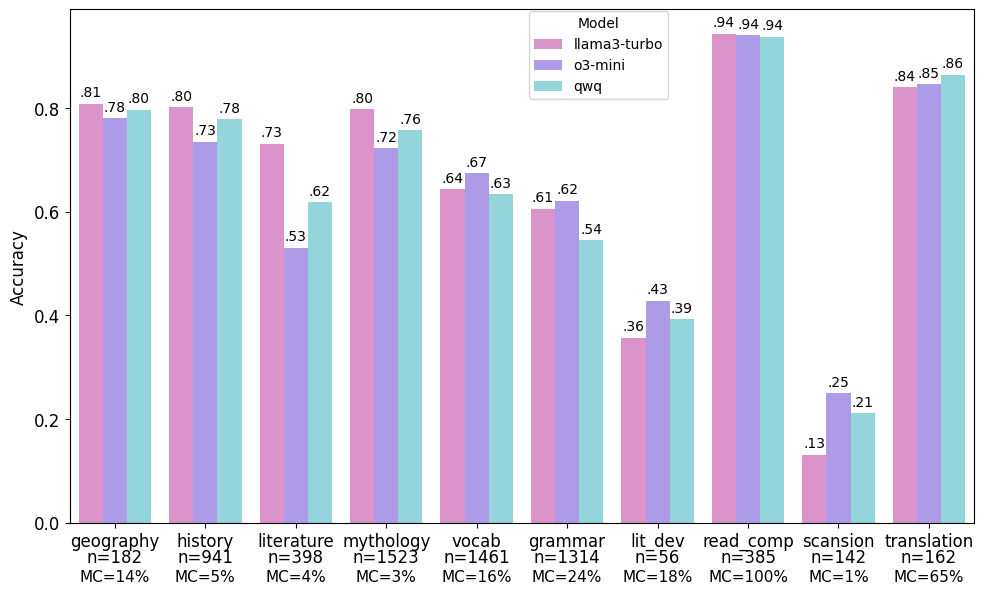

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import copy

colors = {'llama3-turbo':'#e788d2', 'qwq':'#88dee7', 'o3-mini':'#A68EF5'}
content_map = {
    "reading_comprehension": "read_comp",
    "literary_devices": "lit_dev",
    "vocabulary": "vocab"
}
content_table["question_content"] = content_table["question_content"].replace(content_map)
content_table["model"] = content_table["model"].str.replace(r"^score_", "", regex=True)


# Assuming df has columns: question_content, model, accuracy, n_items

ordering = copy.deepcopy(knowledge_vals + skill_vals)
ordering = [content_map[c] if c in content_map else c for c in ordering]
content_table["question_content"] = pd.Categorical(content_table["question_content"],
                                        categories=ordering,
                                        ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=content_table,
    x="question_content",
    y="accuracy",
    hue="model",        # legend will show models
    errorbar=None,      
    palette=colors,
    order=ordering
)

#for i, (content, row) in enumerate(content_table.groupby("question_content").first().iterrows()):
#    n = int(row["n_items"])
#    # place annotation slightly above the tallest bar in that group
#    y = content_table[content_table["question_content"] == content]["accuracy"].max() + 0.01
#    ax.text(i, y, f"n={n}", ha="center", va="bottom", fontsize=10)

# --- Styling ---
#ax.set_xlabel("Question Content", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("") 
#ax.set_title("Accuracy by Question Content and Model", fontsize=14)
plt.xticks(fontsize=12)#rotation=45, ha="right")
plt.yticks(fontsize=12)
plt.legend(
    title="Model",
    loc="upper left",           # try 'upper left', 'lower right', etc.
    bbox_to_anchor=(0.50, 1.01), # fine-tune position (x, y)
    frameon=True,
    fontsize=10,
)

df_labels = content_table.drop_duplicates(subset=["question_content"])

combined_df_short = combined_df.copy()
combined_df_short["question_content"] = combined_df_short["question_content"].replace(content_map)

mc_pct = (
    combined_df_short.assign(is_mc=combined_df_short["question_format"].eq("multiple_choice"))
    .groupby("question_content")["is_mc"]
    .mean()
    .mul(100)
    .round(1)
    .to_dict()
)

for xtick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    cat = label.get_text()
    row = df_labels[df_labels["question_content"] == cat]
    if row.empty:
        continue
    n = int(row.iloc[0]["n_items"])
    pct = mc_pct.get(cat, None)

    # Place below tick using axis transform (so it's fixed relative to axis, not data)
    ax.text(
        xtick, -0.05, f"n={n}",
        ha="center", va="top", fontsize=12, transform=ax.get_xaxis_transform()
    )

    if pct is not None:
        ax.text(
            xtick, -0.09, f"MC={pct:.0f}%",
            ha="center", va="top", fontsize=11, transform=ax.get_xaxis_transform()
    )

for container in ax.containers:
    labels = [f"{p.get_height():.2f}"[1:] if p.get_height() > 0 else "" for p in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)
plt.tight_layout()
plt.show()

In [92]:
accuracy_by(combined_df,
            group_cols=["question_language", "question_content"],
            score_cols=score_cols
            )

,question_language,question_content,model,accuracy,n_items
0,english,geography,score_llama3-turbo,0.816667,180
1,english,geography,score_qwq,0.805556,180
2,english,grammar,score_llama3-turbo,0.567219,1086
3,english,grammar,score_qwq,0.506446,1086
4,english,history,score_llama3-turbo,0.802772,938
5,english,history,score_qwq,0.779318,938
6,english,literary_devices,score_llama3-turbo,0.345455,55
7,english,literary_devices,score_qwq,0.381818,55
8,english,literature,score_llama3-turbo,0.729798,396
9,english,literature,score_qwq,0.616162,396


In [43]:
import numpy as np

In [44]:
def accuracy_by_category(df, group_cols, score_cols, knowledge_vals, skill_vals):
    """
    Compute per-model accuracy aggregated over 'knowledge' and 'skill' categories,
    determined by the *values* in `question_content`.

    df            : DataFrame with columns including question_content and score_*model columns
    group_cols    : column or list of columns to group by (e.g. 'question_language')
    score_cols    : list of model score columns (e.g. ['score_modelA', 'score_modelB'])
    knowledge_vals: list of question_content values belonging to the 'knowledge' category
    skill_vals    : list of question_content values belonging to the 'skill' category
    """

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    # Melt to long format for model-wise accuracy
    long = df.melt(
        id_vars=group_cols + ["question_content"],
        value_vars=score_cols,
        var_name="model",
        value_name="score"
    )
    long["model"] = long["model"].str.replace("^score_", "", regex=True)

    # Assign category based on question_content
    long["category"] = np.select(
        [
            long["question_content"].isin(knowledge_vals),
            long["question_content"].isin(skill_vals)
        ],
        ["knowledge", "skill"],
        default="uncategorized"
    )

    # Group by model, category, and any other grouping columns
    grouped = (
        long.groupby(group_cols + ["model", "category"], dropna=False)
        .agg(accuracy=("score", "mean"), n_items=("score", "size"))
        .reset_index()
    )

    return grouped

In [45]:
accuracy_by_category(
    combined_df,
    group_cols=[], 
    score_cols=score_cols,
    knowledge_vals=knowledge_vals,
    skill_vals=skill_vals
)

,model,category,accuracy,n_items
0,llama3-turbo,knowledge,0.742730,4505
1,llama3-turbo,skill,0.647701,2059
2,o3-mini,knowledge,0.694562,4505
3,o3-mini,skill,0.667557,2059
4,qwq,knowledge,0.710766,4505
5,qwq,skill,0.616294,2059


In [46]:
accuracy_by_category(
    combined_df,
    group_cols=["question_language"],
    score_cols=score_cols,
    knowledge_vals=knowledge_vals,
    skill_vals=skill_vals
)

,question_language,model,category,accuracy,n_items
0,english,llama3-turbo,knowledge,0.744004,4461
1,english,llama3-turbo,skill,0.631784,1678
2,english,o3-mini,knowledge,0.693791,4461
3,english,o3-mini,skill,0.655274,1678
4,english,qwq,knowledge,0.710827,4461
5,english,qwq,skill,0.594825,1678
6,latin,llama3-turbo,knowledge,0.613636,44
7,latin,llama3-turbo,skill,0.717804,381
8,latin,o3-mini,knowledge,0.772727,44
9,latin,o3-mini,skill,0.721654,381


In [83]:
combined_df[(combined_df["question_content"] == "scansion") & (combined_df["source_name"] == "exercises-in-latin-prosody")]

,question_id,source_name,source_year,question_format,question_content,difficulty,question_language,answer_language,answers,passage_id,source_file,multihop,score_llama3-turbo,raw_resp_llama3-turbo,parsed_resp_llama3-turbo,score_qwq,raw_resp_qwq,parsed_resp_qwq
6442,prosody_III.I.10.1,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,latin,"[En, proles antiqua redit; concordia, virtus,]",NaN,prosody_caesura_scansion_english.json,NaN,0.0,To form the line into hexameter or pentameter ...,"En, proles antiqua virtus redit; concordia,",0.0,"<think>\n\nOkay, let's see. The user wants me ...","En, proles antiqua redit virtus, concordia;"
6443,prosody_III.I.10.1,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,latin,"[En, proles antiqua redit; concordia, virtus,]",NaN,prosody_caesura_scansion_latin.json,NaN,1.0,Versum infra positum in hexametrum aut pentame...,"En, proles antiqua redit concordia, virtus",1.0,"<think>\n\nOkay, the user wants me to convert ...","En, proles antiqua redit, concordia, *virtus*,"
6444,prosody_III.I.10.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,latin,[Cumque fide pietas altâ cervice vagantur.],NaN,prosody_caesura_scansion_english.json,NaN,1.0,"To form a hexameter or pentameter verse, we ne...",Cumque fide pietas altâ cervice vagantur.,1.0,"<think>\n\nOkay, so the user wants me to adjus...",Cumque fide pietas altâ cervice vagantur.
6445,prosody_III.I.10.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,latin,[Cumque fide pietas altâ cervice vagantur.],NaN,prosody_caesura_scansion_latin.json,NaN,0.0,"Versum datum est: ""Cumque fide pietas cervice ...",Cumque fide pietas cervice humili vagantur.,0.0,"<think>\n\nOkay, the user wants me to change o...",Cumque fide pietas cervice sublimi vagantur.**
6446,prosody_III.I.11.1,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,latin,"[Robora nec cuneis, et olentem scindere cedrum,]",NaN,prosody_caesura_scansion_english.json,NaN,1.0,"To form a hexameter or pentameter verse, the w...","Robora nec cuneis et olentem scindere cedrum,",0.0,"<think>\n\nOkay, let's see. The user wants me ...","Robora nec cuneis, olentem *et* scindere cedrum,"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6559,prosody_app.I.6.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[small ionic, small ionic, small ionic, small ...",NaN,prosody_feet_questions_latin_with_instr.json,NaN,0.0,Versum poeticum analysandum est. Pedes identif...,"trochee, trochee, dactyl, dactyl, pyrrhic, iam...",0.0,"<think>\n\nAlright, let's tackle this question...","iambus, iambus, pyrrhic, pyrrhic, dactyl, trochee"
6560,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,prosody_feet_questions_english_with_instr.json,NaN,0.0,To determine the name of each foot in the give...,"spondee, spondee, dactyl, dactyl, dactyl, dactyl",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","spondee, pyrrhic, iambus, pyrrhic, trochee, tr..."
6561,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[great ionic, great ionic, dichoree, spondee]",NaN,prosody_feet_questions_latin_with_instr.json,NaN,0.0,Versum poeticum analysamus. Pedes identificemu...,"Spondeus, Trochaeus, Dactylus, Dactylus, Troch...",0.0,"<think>\n\nOkay, let's tackle this question. T...","small_ionic, choriamb, spondee, trochee"
6562,prosody_app.I.6.4,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,prosody_feet_questions_english_with_instr.json,NaN,0.0,To determine the name of each foot in the give...,"dactyl, pyrrhic, pyrrhic, dactyl, dactyl, iamb",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","dactyl,iambus,dactyl,dactyl,amphibrach"


In [47]:
# only grammar and scansion
grammar_subset = combined_df[combined_df["question_content"] == "grammar"]
# of scansion, only those from the source_name "exercises-in-latin-prosody"; grammar, all
scan_subset = combined_df[(combined_df["question_content"] == "scansion") & (combined_df["source_name"] == "exercises-in-latin-prosody")]
# merge the two
combined_subset = pd.concat([grammar_subset, scan_subset])
combined_subset


,question_id,source_name,source_year,question_format,question_content,difficulty,question_language,answer_language,answers,passage_id,...,multihop,score_llama3-turbo,raw_resp_llama3-turbo,parsed_resp_llama3-turbo,score_qwq,raw_resp_qwq,parsed_resp_qwq,score_o3-mini,raw_resp_o3-mini,parsed_resp_o3-mini
3,NJCL-Certamen_1996_10_3,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[RIDĒRI],NaN,...,False,0.0,"To change ""rīsum īrī"" to the present tense, we...",rideo,0.0,"<think>\n\nOkay, the user wants to change ""rīs...",īre,0.00,We begin with the “principal‐parts” of a depon...,īror
8,NJCL-Certamen_1996_10a_11,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[AGENCY],NaN,...,False,0.0,"The sentence ""Lucius ab ursā caesus est"" is an...",Agent,0.0,"<think>\nOkay, so the user is asking about the...",Agent,0.00,"In the sentence ""Lucius ab ursā caesus est,"" t...",Agent
11,NJCL-Certamen_1996_10a_18,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[Agency],NaN,...,False,0.0,"The sentence ""Iūdicī sōlī dēlīberandum est"" is...",Dative,0.0,"<think>\n\nOkay, let's tackle this question. T...",Agent,0.00,In this sentence the impersonal gerundive cons...,Ethical
19,NJCL-Certamen_1996_10a_32,NJCL-Certamen,1996,multiple_choice,grammar,unknown,english,latin,[A: custōs],,...,NaN,1.0,To determine which Latin noun does not belong ...,A,1.0,"<think>\n\nOkay, so I need to figure out which...",A,1.00,Let’s examine the gender of each noun:\n\n• cu...,A
25,NJCL-Certamen_1996_10a_42,NJCL-Certamen,1996,multiple_choice,grammar,unknown,english,latin,[C: tellūs],,...,NaN,1.0,To determine which Latin noun does not belong ...,C,1.0,"<think>\n\nOkay, let's tackle this Latin noun ...",C,0.00,Let’s review the genders of the Latin nouns:\n...,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6559,prosody_app.I.6.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[small ionic, small ionic, small ionic, small ...",NaN,...,NaN,0.0,Versum poeticum analysandum est. Pedes identif...,"trochee, trochee, dactyl, dactyl, pyrrhic, iam...",0.0,"<think>\n\nAlright, let's tackle this question...","iambus, iambus, pyrrhic, pyrrhic, dactyl, trochee",0.00,Legendo hunc versum “Simul unctos | Tiberinis ...,"choriamb, choriamb, choriamb, choriamb"
6560,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,...,NaN,0.0,To determine the name of each foot in the give...,"spondee, spondee, dactyl, dactyl, dactyl, dactyl",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","spondee, pyrrhic, iambus, pyrrhic, trochee, tr...",0.25,We can show that if the line\n\n Hās cūm gĕmĭ...,"great ionic, dichoree, second epitrit, trochee"
6561,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[great ionic, great ionic, dichoree, spondee]",NaN,...,NaN,0.0,Versum poeticum analysamus. Pedes identificemu...,"Spondeus, Trochaeus, Dactylus, Dactylus, Troch...",0.0,"<think>\n\nOkay, let's tackle this question. T...","small_ionic, choriamb, spondee, trochee",0.00,"Dividamus versum in septem pedes, singulos duo...","spondee, pyrrhic, iambus, pyrrhic, trochee, tr..."
6562,prosody_app.I.6.4,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,...,NaN,0.0,To determine the name of each foot in the give...,"dactyl, pyrrhic, pyrrhic, dactyl, dactyl, iamb",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","dactyl,iambus,dactyl,dactyl,amphibrach",0.00,Below is one traditional solution. In one acce...,"small ionic, dactyl, choriamb, iambus"


In [85]:
combined_subset[combined_subset["question_content"] == "scansion"]

,question_id,source_name,source_year,question_format,question_content,difficulty,question_language,answer_language,answers,passage_id,source_file,multihop,score_llama3-turbo,raw_resp_llama3-turbo,parsed_resp_llama3-turbo,score_qwq,raw_resp_qwq,parsed_resp_qwq
6442,prosody_III.I.10.1,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,latin,"[En, proles antiqua redit; concordia, virtus,]",NaN,prosody_caesura_scansion_english.json,NaN,0.0,To form the line into hexameter or pentameter ...,"En, proles antiqua virtus redit; concordia,",0.0,"<think>\n\nOkay, let's see. The user wants me ...","En, proles antiqua redit virtus, concordia;"
6443,prosody_III.I.10.1,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,latin,"[En, proles antiqua redit; concordia, virtus,]",NaN,prosody_caesura_scansion_latin.json,NaN,1.0,Versum infra positum in hexametrum aut pentame...,"En, proles antiqua redit concordia, virtus",1.0,"<think>\n\nOkay, the user wants me to convert ...","En, proles antiqua redit, concordia, *virtus*,"
6444,prosody_III.I.10.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,latin,[Cumque fide pietas altâ cervice vagantur.],NaN,prosody_caesura_scansion_english.json,NaN,1.0,"To form a hexameter or pentameter verse, we ne...",Cumque fide pietas altâ cervice vagantur.,1.0,"<think>\n\nOkay, so the user wants me to adjus...",Cumque fide pietas altâ cervice vagantur.
6445,prosody_III.I.10.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,latin,[Cumque fide pietas altâ cervice vagantur.],NaN,prosody_caesura_scansion_latin.json,NaN,0.0,"Versum datum est: ""Cumque fide pietas cervice ...",Cumque fide pietas cervice humili vagantur.,0.0,"<think>\n\nOkay, the user wants me to change o...",Cumque fide pietas cervice sublimi vagantur.**
6446,prosody_III.I.11.1,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,latin,"[Robora nec cuneis, et olentem scindere cedrum,]",NaN,prosody_caesura_scansion_english.json,NaN,1.0,"To form a hexameter or pentameter verse, the w...","Robora nec cuneis et olentem scindere cedrum,",0.0,"<think>\n\nOkay, let's see. The user wants me ...","Robora nec cuneis, olentem *et* scindere cedrum,"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6559,prosody_app.I.6.2,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[small ionic, small ionic, small ionic, small ...",NaN,prosody_feet_questions_latin_with_instr.json,NaN,0.0,Versum poeticum analysandum est. Pedes identif...,"trochee, trochee, dactyl, dactyl, pyrrhic, iam...",0.0,"<think>\n\nAlright, let's tackle this question...","iambus, iambus, pyrrhic, pyrrhic, dactyl, trochee"
6560,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,prosody_feet_questions_english_with_instr.json,NaN,0.0,To determine the name of each foot in the give...,"spondee, spondee, dactyl, dactyl, dactyl, dactyl",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","spondee, pyrrhic, iambus, pyrrhic, trochee, tr..."
6561,prosody_app.I.6.3,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,latin,english,"[great ionic, great ionic, dichoree, spondee]",NaN,prosody_feet_questions_latin_with_instr.json,NaN,0.0,Versum poeticum analysamus. Pedes identificemu...,"Spondeus, Trochaeus, Dactylus, Dactylus, Troch...",0.0,"<think>\n\nOkay, let's tackle this question. T...","small_ionic, choriamb, spondee, trochee"
6562,prosody_app.I.6.4,exercises-in-latin-prosody,1823,short_answer,scansion,unknown,english,english,"[great ionic, great ionic, dichoree, spondee]",NaN,prosody_feet_questions_english_with_instr.json,NaN,0.0,To determine the name of each foot in the give...,"dactyl, pyrrhic, pyrrhic, dactyl, dactyl, iamb",0.0,"<think>\n\nOkay, let's tackle this problem. Th...","dactyl,iambus,dactyl,dactyl,amphibrach"


In [48]:
lang_pairs = accuracy_by(
    combined_subset,
    group_cols=["question_language", "answer_language", "question_content"],
    score_cols=score_cols,
    #knowledge_vals=knowledge_vals,
    #skill_vals=skill_vals
)
lang_pairs

,question_language,answer_language,question_content,model,accuracy,n_items
0,english,english,grammar,score_llama3-turbo,0.671875,192
1,english,english,grammar,score_o3-mini,0.656250,192
2,english,english,grammar,score_qwq,0.572917,192
3,english,english,scansion,score_llama3-turbo,0.106667,20
4,english,english,scansion,score_o3-mini,0.577500,20
5,english,english,scansion,score_qwq,0.305833,20
6,english,latin,grammar,score_llama3-turbo,0.544743,894
7,english,latin,grammar,score_o3-mini,0.581655,894
8,english,latin,grammar,score_qwq,0.492170,894
9,english,latin,scansion,score_llama3-turbo,0.121951,41


In [140]:
combined_subset[(combined_subset['question_language']=='latin') & (combined_subset['answer_language']=='english')]['source_name'].value_counts()

source_name
NLE                           122
exercises-in-latin-prosody     20
Name: count, dtype: int64

In [49]:
lang_table = accuracy_by(
    combined_subset,
    group_cols=["question_language",  "question_content"],
    score_cols=score_cols,
    #knowledge_vals=knowledge_vals,
    #skill_vals=skill_vals
)
lang_table

,question_language,question_content,model,accuracy,n_items
0,english,grammar,score_llama3-turbo,0.567219,1086
1,english,grammar,score_o3-mini,0.594843,1086
2,english,grammar,score_qwq,0.506446,1086
3,english,scansion,score_llama3-turbo,0.116940,61
4,english,scansion,score_o3-mini,0.238525,61
5,english,scansion,score_qwq,0.182240,61
6,latin,grammar,score_llama3-turbo,0.789474,228
7,latin,grammar,score_o3-mini,0.745614,228
8,latin,grammar,score_qwq,0.728070,228
9,latin,scansion,score_llama3-turbo,0.073497,61


In [50]:
scan_lang = lang_table[lang_table['question_content'] == 'scansion']
scan_lang

,question_language,question_content,model,accuracy,n_items
3,english,scansion,score_llama3-turbo,0.116940,61
4,english,scansion,score_o3-mini,0.238525,61
5,english,scansion,score_qwq,0.182240,61
9,latin,scansion,score_llama3-turbo,0.073497,61
10,latin,scansion,score_o3-mini,0.245082,61
11,latin,scansion,score_qwq,0.210383,61


In [51]:
gram_lang = lang_pairs[lang_pairs['question_content'] == 'grammar']
gram_lang

,question_language,answer_language,question_content,model,accuracy,n_items
0,english,english,grammar,score_llama3-turbo,0.671875,192
1,english,english,grammar,score_o3-mini,0.656250,192
2,english,english,grammar,score_qwq,0.572917,192
6,english,latin,grammar,score_llama3-turbo,0.544743,894
7,english,latin,grammar,score_o3-mini,0.581655,894
8,english,latin,grammar,score_qwq,0.492170,894
12,latin,english,grammar,score_llama3-turbo,0.942623,122
13,latin,english,grammar,score_o3-mini,0.975410,122
14,latin,english,grammar,score_qwq,0.926230,122
18,latin,latin,grammar,score_llama3-turbo,0.613208,106


In [52]:
def label_lang_pair(row):
    q_lang = row['question_language']
    a_lang = row['answer_language']
    str_ = q_lang[:2] + '-' + a_lang[:2]
    return str_

In [53]:
gram_lang['lang_pair']= gram_lang.apply(label_lang_pair, axis=1)
gram_lang

/scratch/login/ipykernel_1469682/3804809301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gram_lang['lang_pair']= gram_lang.apply(label_lang_pair, axis=1)


,question_language,answer_language,question_content,model,accuracy,n_items,lang_pair
0,english,english,grammar,score_llama3-turbo,0.671875,192,en-en
1,english,english,grammar,score_o3-mini,0.656250,192,en-en
2,english,english,grammar,score_qwq,0.572917,192,en-en
6,english,latin,grammar,score_llama3-turbo,0.544743,894,en-la
7,english,latin,grammar,score_o3-mini,0.581655,894,en-la
8,english,latin,grammar,score_qwq,0.492170,894,en-la
12,latin,english,grammar,score_llama3-turbo,0.942623,122,la-en
13,latin,english,grammar,score_o3-mini,0.975410,122,la-en
14,latin,english,grammar,score_qwq,0.926230,122,la-en
18,latin,latin,grammar,score_llama3-turbo,0.613208,106,la-la


In [54]:
gram_lang["model"] = gram_lang["model"].str.replace(r"^score_", "", regex=True)
gram_lang

/scratch/login/ipykernel_1469682/3114267863.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gram_lang["model"] = gram_lang["model"].str.replace(r"^score_", "", regex=True)


,question_language,answer_language,question_content,model,accuracy,n_items,lang_pair
0,english,english,grammar,llama3-turbo,0.671875,192,en-en
1,english,english,grammar,o3-mini,0.656250,192,en-en
2,english,english,grammar,qwq,0.572917,192,en-en
6,english,latin,grammar,llama3-turbo,0.544743,894,en-la
7,english,latin,grammar,o3-mini,0.581655,894,en-la
8,english,latin,grammar,qwq,0.492170,894,en-la
12,latin,english,grammar,llama3-turbo,0.942623,122,la-en
13,latin,english,grammar,o3-mini,0.975410,122,la-en
14,latin,english,grammar,qwq,0.926230,122,la-en
18,latin,latin,grammar,llama3-turbo,0.613208,106,la-la


In [55]:
n1 = 4
n2 = 2

bar_width = 1.5

In [64]:
combined_subset_short = combined_subset.copy()
combined_subset_short["question_content"] = combined_subset_short["question_content"].replace(content_map)

combined_subset_gram = combined_subset[combined_subset['question_content'] == 'grammar']
combined_subset_scan = combined_subset[combined_subset['question_content'] == 'scansion']
combined_subset_gram['lang_pair'] = combined_subset_gram.apply(label_lang_pair, axis=1)
combined_subset_scan['lang_pair'] = combined_subset_scan.apply(label_lang_pair, axis=1)
combined_subset_gram
#colors = {'llama3-turbo':'#e788d2', 'qwq':'#88dee7'}

/scratch/login/ipykernel_1469682/741136340.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_subset_gram['lang_pair'] = combined_subset_gram.apply(label_lang_pair, axis=1)
/scratch/login/ipykernel_1469682/741136340.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_subset_scan['lang_pair'] = combined_subset_scan.apply(label_lang_pair, axis=1)


,question_id,source_name,source_year,question_format,question_content,difficulty,question_language,answer_language,answers,passage_id,...,score_llama3-turbo,raw_resp_llama3-turbo,parsed_resp_llama3-turbo,score_qwq,raw_resp_qwq,parsed_resp_qwq,score_o3-mini,raw_resp_o3-mini,parsed_resp_o3-mini,lang_pair
3,NJCL-Certamen_1996_10_3,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[RIDĒRI],NaN,...,0.0,"To change ""rīsum īrī"" to the present tense, we...",rideo,0.0,"<think>\n\nOkay, the user wants to change ""rīs...",īre,0.0,We begin with the “principal‐parts” of a depon...,īror,en-la
8,NJCL-Certamen_1996_10a_11,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[AGENCY],NaN,...,0.0,"The sentence ""Lucius ab ursā caesus est"" is an...",Agent,0.0,"<think>\nOkay, so the user is asking about the...",Agent,0.0,"In the sentence ""Lucius ab ursā caesus est,"" t...",Agent,en-la
11,NJCL-Certamen_1996_10a_18,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[Agency],NaN,...,0.0,"The sentence ""Iūdicī sōlī dēlīberandum est"" is...",Dative,0.0,"<think>\n\nOkay, let's tackle this question. T...",Agent,0.0,In this sentence the impersonal gerundive cons...,Ethical,en-la
19,NJCL-Certamen_1996_10a_32,NJCL-Certamen,1996,multiple_choice,grammar,unknown,english,latin,[A: custōs],,...,1.0,To determine which Latin noun does not belong ...,A,1.0,"<think>\n\nOkay, so I need to figure out which...",A,1.0,Let’s examine the gender of each noun:\n\n• cu...,A,en-la
25,NJCL-Certamen_1996_10a_42,NJCL-Certamen,1996,multiple_choice,grammar,unknown,english,latin,[C: tellūs],,...,1.0,To determine which Latin noun does not belong ...,C,1.0,"<think>\n\nOkay, let's tackle this Latin noun ...",C,0.0,Let’s review the genders of the Latin nouns:\n...,E,en-la
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,latin-grammar-junior-scholarship_96.1.2,latin-grammar-junior-scholarship,1884,short_answer,grammar,unknown,english,latin,[Sapphūs],NaN,...,0.0,To form the genitive singular of the Greek nam...,Sapphōs,0.0,"<think>\nOkay, the user is asking for the geni...",Sapphon,0.0,"In Classical Greek, Sappho’s name is rendered ...",Sapphōos,en-la
6394,latin-grammar-junior-scholarship_96.1.3,latin-grammar-junior-scholarship,1884,short_answer,grammar,unknown,english,latin,[Quiritīs],NaN,...,0.0,To determine the genitive singular of *Quiris*...,Quiris,0.0,"<think>\nOkay, the user is asking for the geni...",Quirīs,1.0,The noun Quiris belongs to the third declensio...,Quiritis,en-la
6395,latin-grammar-junior-scholarship_96.1.4,latin-grammar-junior-scholarship,1884,short_answer,grammar,unknown,english,latin,[incudis],NaN,...,1.0,"To determine the genitive singular of *incus*,...",incudis,0.0,"<think>\nOkay, the user is asking for the geni...",incī,1.0,The Latin noun incus is of the third declensio...,incudis,en-la
6396,latin-grammar-junior-scholarship_96.1.5,latin-grammar-junior-scholarship,1884,short_answer,grammar,unknown,english,latin,[gregis],NaN,...,1.0,"The Latin word *grex* means ""flock"" or ""herd""....",gregis,1.0,"<think>\nOkay, the user is asking for the geni...",gregis,1.0,The noun grex is a third-declension noun in La...,gregis,en-la


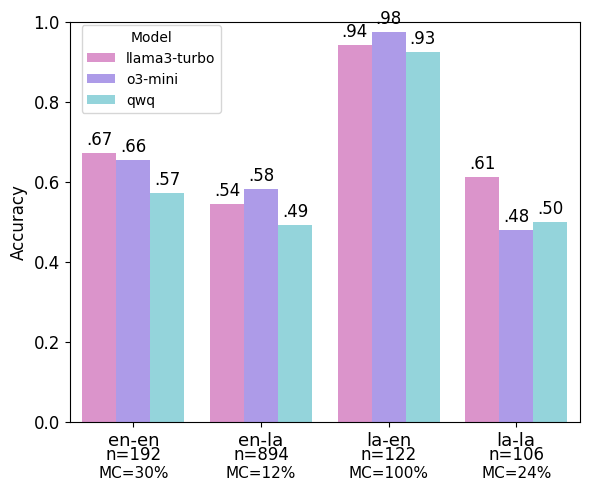

In [67]:
#colors = {'llama3-turbo':'#e788d2', 'qwq':'#88dee7'}

mc_pct = (
    combined_subset_gram.assign(is_mc=combined_subset_gram["question_format"].eq("multiple_choice"))
    .groupby("lang_pair")["is_mc"]
    .mean()
    .mul(100)
    .round(1)
    .to_dict()
)


plt.figure(figsize=(n1*bar_width, 5))
ax = sns.barplot(
    data=gram_lang,
    x="lang_pair",
    y="accuracy",
    hue="model",        # legend will show models
    errorbar=None,      
    palette=colors,
)

#for i, (content, row) in enumerate(content_table.groupby("question_content").first().iterrows()):
#    n = int(row["n_items"])
#    # place annotation slightly above the tallest bar in that group
#    y = content_table[content_table["question_content"] == content]["accuracy"].max() + 0.01
#    ax.text(i, y, f"n={n}", ha="center", va="bottom", fontsize=10)

# --- Styling ---
#ax.set_xlabel("Question Content", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("") 
#ax.set_title("Accuracy by Question Content and Model", fontsize=14)
plt.xticks(fontsize=13)#rotation=45, ha="right")
plt.yticks(fontsize=12)
plt.legend(
    title="Model",
    loc="upper left",           # try 'upper left', 'lower right', etc.
    bbox_to_anchor=(0.01, 1.01), # fine-tune position (x, y)
    frameon=True,
    fontsize=10,
)
plt.ylim(0,1)
df_labels = gram_lang.drop_duplicates(subset=["lang_pair"])
for xtick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    cat = label.get_text()
    row = df_labels[df_labels["lang_pair"] == cat]
    if row.empty:
        continue
    n = int(row.iloc[0]["n_items"])
    pct = mc_pct.get(cat, None)
    # Place below tick using axis transform (so it's fixed relative to axis, not data)
    ax.text(
        xtick, -0.06, f"n={n}",
        ha="center", va="top", fontsize=12, transform=ax.get_xaxis_transform()
    )
    if pct is not None:
        ax.text(
            xtick, -0.11, f"MC={pct:.0f}%",
            ha="center", va="top", fontsize=11, transform=ax.get_xaxis_transform()
        )

for container in ax.containers:
    labels = [f"{p.get_height():.2f}"[1:] if p.get_height() > 0 else "" for p in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=12)

plt.tight_layout()
plt.show()

In [70]:
mc_pct

{'en-en': 0.0, 'en-la': 0.0, 'la-en': 0.0, 'la-la': 0.0}

/scratch/login/ipykernel_1469682/2825687836.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scan_lang["model"] = scan_lang["model"].str.replace(r"^score_", "", regex=True)


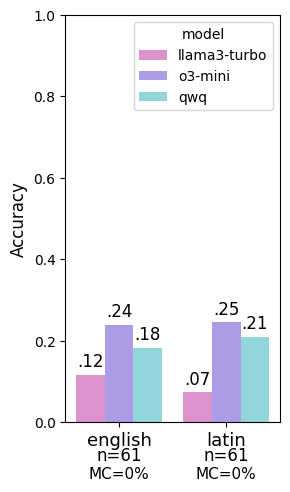

In [71]:
#colors = {'llama3-turbo':'#e788d2', 'qwq':'#88dee7'}
mc_pct = (
    combined_subset_scan.assign(is_mc=combined_subset_scan["question_format"].eq("multiple_choice"))
    .groupby("question_language")["is_mc"]
    .mean()
    .mul(100)
    .round(1)
    .to_dict()
)


scan_lang["model"] = scan_lang["model"].str.replace(r"^score_", "", regex=True)

plt.figure(figsize=(n2*bar_width, 5))
ax = sns.barplot(
    data=scan_lang,
    x="question_language",
    y="accuracy",
    hue="model",        # legend will show models
    errorbar=None,      
    palette=colors,
)

#for i, (content, row) in enumerate(content_table.groupby("question_content").first().iterrows()):
#    n = int(row["n_items"])
#    # place annotation slightly above the tallest bar in that group
#    y = content_table[content_table["question_content"] == content]["accuracy"].max() + 0.01
#    ax.text(i, y, f"n={n}", ha="center", va="bottom", fontsize=10)

# --- Styling ---
#ax.set_xlabel("Question Content", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xlabel("") 
#ax.set_title("Accuracy by Question Content and Model", fontsize=14)
plt.xticks(fontsize=13)#rotation=45, ha="right")
'''
plt.legend(
    title="Model",
    loc="upper left",           # try 'upper left', 'lower right', etc.
    bbox_to_anchor=(0.01, 1.01), # fine-tune position (x, y)
    frameon=True,
    fontsize=12,
)
'''
plt.ylim(0,1)
df_labels = scan_lang.drop_duplicates(subset=["question_language"])
for xtick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    cat = label.get_text()
    row = df_labels[df_labels["question_language"] == cat]
    if row.empty:
        continue
    n = int(row.iloc[0]["n_items"])
    pct = mc_pct.get(cat, None)
    # Place below tick using axis transform (so it's fixed relative to axis, not data)
    ax.text(
        xtick, -0.06, f"n={n}",
        ha="center", va="top", fontsize=12, transform=ax.get_xaxis_transform()
    )
    if pct is not None:
        ax.text(
            xtick, -0.11, f"MC={pct:.0f}%",
            ha="center", va="top", fontsize=11, transform=ax.get_xaxis_transform()
        )

for container in ax.containers:
    labels = [f"{p.get_height():.2f}"[1:] if p.get_height() > 0 else "" for p in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=12)


plt.tight_layout()
plt.show()

In [72]:
accuracy_by_category(
    combined_df,
    group_cols=["answer_language"],
    score_cols=score_cols,
    knowledge_vals=knowledge_vals,
    skill_vals=skill_vals
)

,answer_language,model,category,accuracy,n_items
0,english,llama3-turbo,knowledge,0.731509,1352
1,english,llama3-turbo,skill,0.826045,853
2,english,o3-mini,knowledge,0.730030,1352
3,english,o3-mini,skill,0.850528,853
4,english,qwq,knowledge,0.708580,1352
5,english,qwq,skill,0.812368,853
6,latin,llama3-turbo,knowledge,0.747542,3153
7,latin,llama3-turbo,skill,0.521559,1206
8,latin,o3-mini,knowledge,0.679353,3153
9,latin,o3-mini,skill,0.538143,1206


In [73]:
accuracy_by_category(
    combined_df,
    group_cols=["question_language", "answer_language"],
    score_cols=score_cols,
    knowledge_vals=knowledge_vals,
    skill_vals=skill_vals
)

,question_language,answer_language,model,category,accuracy,n_items
0,english,english,llama3-turbo,knowledge,0.731889,1339
1,english,english,llama3-turbo,skill,0.803441,620
2,english,english,o3-mini,knowledge,0.728902,1339
3,english,english,o3-mini,skill,0.818629,620
4,english,english,qwq,knowledge,0.707244,1339
5,english,english,qwq,skill,0.777608,620
6,english,latin,llama3-turbo,knowledge,0.749199,3122
7,english,latin,llama3-turbo,skill,0.531191,1058
8,english,latin,o3-mini,knowledge,0.678732,3122
9,english,latin,o3-mini,skill,0.559546,1058


In [74]:


multihop_df = combined_df[(combined_df['multihop'] == True) | (combined_df['multihop'] == False)]
multihop_df = multihop_df[multihop_df['question_content'] != 'translation']
multihop_df

,question_id,source_name,source_year,question_format,question_content,difficulty,question_language,answer_language,answers,passage_id,...,multihop,score_llama3-turbo,raw_resp_llama3-turbo,parsed_resp_llama3-turbo,score_qwq,raw_resp_qwq,parsed_resp_qwq,score_o3-mini,raw_resp_o3-mini,parsed_resp_o3-mini
0,NJCL-Certamen_1996_10_0,NJCL-Certamen,1996,short_answer,mythology,unknown,english,english,[DAMASISTRATUS],NaN,...,True,0.0,"According to Greek mythology, King Polybus of ...",Polybus,0.0,"<think>\nOkay, so the user is asking about the...",Adrastus,0.0,I’m afraid that the answer is not obvious. In ...,Thespius
1,NJCL-Certamen_1996_10_10,NJCL-Certamen,1996,short_answer,history,unknown,english,latin,[JULIA],NaN,...,False,1.0,"The First Triumvirate, a powerful alliance in ...",Julia,1.0,"<think>\nOkay, so the question is asking whose...",Julia,1.0,The answer is Julia. She was the daughter of J...,Julia
2,NJCL-Certamen_1996_10_11,NJCL-Certamen,1996,short_answer,mythology,unknown,english,latin,[LABDACUS],NaN,...,True,1.0,"To answer this question, we must delve into th...",Labdacus,1.0,"<think>\nOkay, so the question is asking about...",Labdacus,1.0,"In Greek mythology, the Theban royal line is t...",Labdacus
3,NJCL-Certamen_1996_10_3,NJCL-Certamen,1996,short_answer,grammar,unknown,english,latin,[RIDĒRI],NaN,...,False,0.0,"To change ""rīsum īrī"" to the present tense, we...",rideo,0.0,"<think>\n\nOkay, the user wants to change ""rīs...",īre,0.0,We begin with the “principal‐parts” of a depon...,īror
4,NJCL-Certamen_1996_10_4,NJCL-Certamen,1996,short_answer,geography,unknown,english,latin,[DACIA],NaN,...,True,1.0,The Roman province that consisted largely of t...,Dacia,1.0,"<think>\n\nOkay, the user is asking about a Ro...",Dacia,1.0,The province you’re referring to is Dacia. Emp...,Dacia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6437,latin-grammar-junior-scholarship_app.V.1.1,latin-grammar-junior-scholarship,1884,short_answer,vocabulary,unknown,english,english,[Over-robe.],NaN,...,False,0.0,"In ancient Rome, a toga was a distinctive garm...",Toga,0.0,"<think>\nOkay, the user is asking, ""What is a ...",Toga,0.0,"In ancient Rome the toga was a distinctive, se...",Garment
6438,latin-grammar-junior-scholarship_app.V.1.2,latin-grammar-junior-scholarship,1884,short_answer,vocabulary,unknown,english,english,[Under-garment.],NaN,...,False,0.0,"In ancient Roman clothing, a tunica was a type...",Tunic,0.0,"<think>\nOkay, the user is asking what a tunic...",Tunic,0.0,A tunica was a basic garment in ancient Roman ...,Tunic
6439,latin-grammar-junior-scholarship_app.V.10.16,latin-grammar-junior-scholarship,1884,short_answer,vocabulary,unknown,english,english,[Embezzlement.],NaN,...,False,0.0,"In the context of Roman law, ""res repetundae"" ...",Corruption,0.0,"<think>\nOkay, the user is asking for the defi...",Repetundae,0.0,"In Roman legal terminology, res repetundae ref...",Restitution
6440,latin-grammar-junior-scholarship_app.V.9.1,latin-grammar-junior-scholarship,1884,short_answer,vocabulary,unknown,english,latin,[*Carceres*],NaN,...,False,0.0,"In Latin, the term for ""starting-post"" is deri...",Meta,1.0,"<think>\nOkay, the user is asking for the Lati...",carceres,0.0,One classical Latin term that was used in the ...,meta


In [75]:
multihop_df['question_content'].unique()

array(['mythology', 'history', 'grammar', 'geography', 'vocabulary',
       'literature', 'literary_devices', 'scansion'], dtype=object)

In [76]:
accuracy_by_category(
    multihop_df,
    group_cols =['question_language', 'multihop'],
    score_cols=score_cols,
    skill_vals=skill_vals,
    knowledge_vals=knowledge_vals
)

,question_language,multihop,model,category,accuracy,n_items
0,english,False,llama3-turbo,knowledge,0.725997,3135
1,english,False,llama3-turbo,skill,0.502203,908
2,english,False,o3-mini,knowledge,0.665072,3135
3,english,False,o3-mini,skill,0.529736,908
4,english,False,qwq,knowledge,0.683254,3135
5,english,False,qwq,skill,0.438326,908
6,english,True,llama3-turbo,knowledge,0.753830,979
7,english,True,llama3-turbo,skill,0.584416,77
8,english,True,o3-mini,knowledge,0.709908,979
9,english,True,o3-mini,skill,0.636364,77


In [77]:
accuracy_by_category(
    multihop_df,
    group_cols =['multihop'],
    score_cols=score_cols,
    skill_vals=skill_vals,
    knowledge_vals=knowledge_vals
)

,multihop,model,category,accuracy,n_items
0,False,llama3-turbo,knowledge,0.725577,3163
1,False,llama3-turbo,skill,0.503049,984
2,False,o3-mini,knowledge,0.666140,3163
3,False,o3-mini,skill,0.516260,984
4,False,qwq,knowledge,0.683844,3163
5,False,qwq,skill,0.432927,984
6,True,llama3-turbo,knowledge,0.750254,985
7,True,llama3-turbo,skill,0.602410,83
8,True,o3-mini,knowledge,0.708629,985
9,True,o3-mini,skill,0.614458,83


In [78]:
accuracy_by(
    multihop_df,
    group_cols =['multihop'],
    score_cols=score_cols,
)

,multihop,model,accuracy,n_items
0,False,score_llama3-turbo,0.672776,4147
1,False,score_o3-mini,0.630576,4147
2,False,score_qwq,0.624307,4147
3,True,score_llama3-turbo,0.738764,1068
4,True,score_o3-mini,0.701311,1068
5,True,score_qwq,0.709738,1068


In [79]:
multihop_table = accuracy_by(
    multihop_df,
    group_cols =['question_content', 'multihop'],
    score_cols=score_cols,
)
multihop_table

,question_content,multihop,model,accuracy,n_items
0,geography,False,score_llama3-turbo,0.757576,99
1,geography,False,score_o3-mini,0.707071,99
2,geography,False,score_qwq,0.737374,99
3,geography,True,score_llama3-turbo,0.877193,57
4,geography,True,score_o3-mini,0.842105,57
5,geography,True,score_qwq,0.859649,57
6,grammar,False,score_llama3-turbo,0.516234,924
7,grammar,False,score_o3-mini,0.528139,924
8,grammar,False,score_qwq,0.441558,924
9,grammar,True,score_llama3-turbo,0.628205,78


In [83]:
llama_multihop = multihop_table[multihop_table['model'] == 'score_llama3-turbo']
qwq_multihop = multihop_table[multihop_table['model'] == 'score_qwq']
o3_multihop = multihop_table[multihop_table['model'] == 'score_o3-mini']


In [84]:

# drop question content if "scansion" or "literary_devices"
idx = llama_multihop.where((llama_multihop['question_content'] == 'scansion') |(llama_multihop['question_content'] == 'literary_devices')).dropna()
llama_multihop.drop(idx.index, inplace=True)

idx = qwq_multihop.where((qwq_multihop['question_content'] == 'scansion') |(qwq_multihop['question_content'] == 'literary_devices')).dropna()
qwq_multihop.drop(idx.index, inplace=True)

idx = o3_multihop.where((o3_multihop['question_content'] == 'scansion') |(o3_multihop['question_content'] == 'literary_devices')).dropna()
o3_multihop.drop(idx.index, inplace=True)

/scratch/login/ipykernel_1469682/2769694865.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llama_multihop.drop(idx.index, inplace=True)
/scratch/login/ipykernel_1469682/2769694865.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qwq_multihop.drop(idx.index, inplace=True)
/scratch/login/ipykernel_1469682/2769694865.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o3_multihop.drop(idx.index, inplace=True)


<Axes: xlabel='question_content', ylabel='accuracy'>

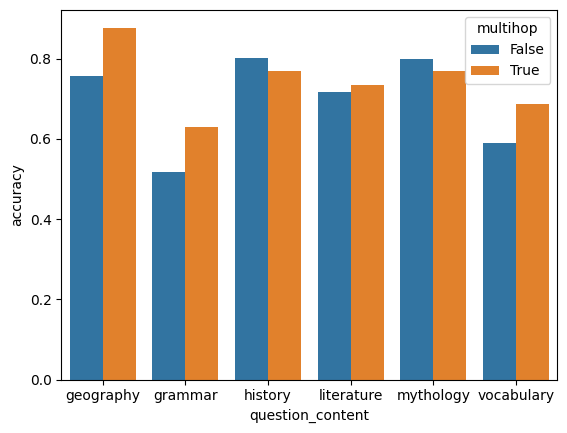

In [85]:
sns.barplot(llama_multihop, 
            x= llama_multihop['question_content'], 
            y=llama_multihop['accuracy'], 
            hue=llama_multihop['multihop'])

<Axes: xlabel='question_content', ylabel='accuracy'>

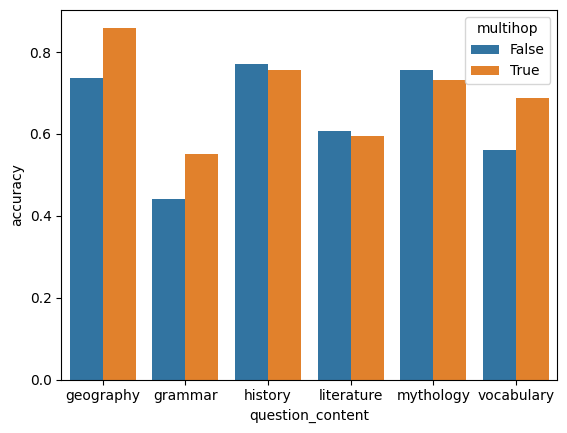

In [86]:
sns.barplot(qwq_multihop, 
            x= qwq_multihop['question_content'], 
            y=qwq_multihop['accuracy'], 
            hue=qwq_multihop['multihop'])

<Axes: xlabel='question_content', ylabel='accuracy'>

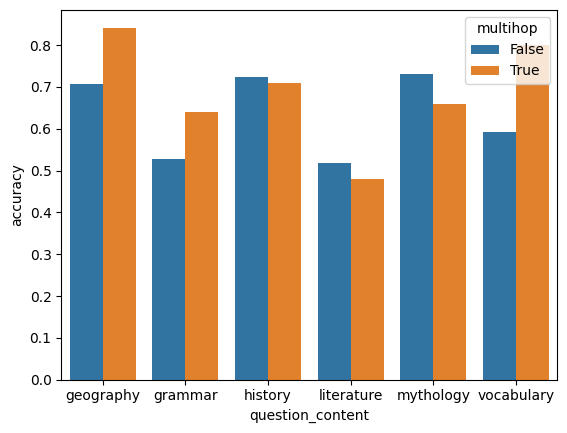

In [87]:
sns.barplot(o3_multihop, 
            x= o3_multihop['question_content'], 
            y=o3_multihop['accuracy'], 
            hue=o3_multihop['multihop'])

In [119]:
def multihop_diff(df, model_name):
    pivot = (
        df.pivot(index="question_content", columns="multihop", values="accuracy")
          .rename(columns={True: "True", False: "False"})  # if bools
    )
    pivot["diff"] = pivot["True"] - pivot["False"] 
    pivot["model"] = model_name
    return pivot.reset_index()[["question_content", "model", "diff"]]

llama_diff = multihop_diff(llama_multihop, "llama3-turbo")
qwq_diff = multihop_diff(qwq_multihop, "qwq")
o3_diff = multihop_diff(o3_multihop, "o3-mini")

# Combine all into one dataframe for plotting
diff_df = pd.concat([llama_diff, qwq_diff, o3_diff], ignore_index=True)

In [120]:
diff_df

multihop,question_content,model,diff
0,geography,llama3-turbo,0.119617
1,grammar,llama3-turbo,0.111971
2,history,llama3-turbo,-0.032796
3,literature,llama3-turbo,0.018006
4,mythology,llama3-turbo,-0.029499
5,vocabulary,llama3-turbo,0.099127
6,geography,qwq,0.122275
7,grammar,qwq,0.109724
8,history,qwq,-0.012465
9,literature,qwq,-0.012324


In [101]:
multihop_ordering = ['geography', 'history', 'literature', 'mythology', 'vocabulary', 'grammar']

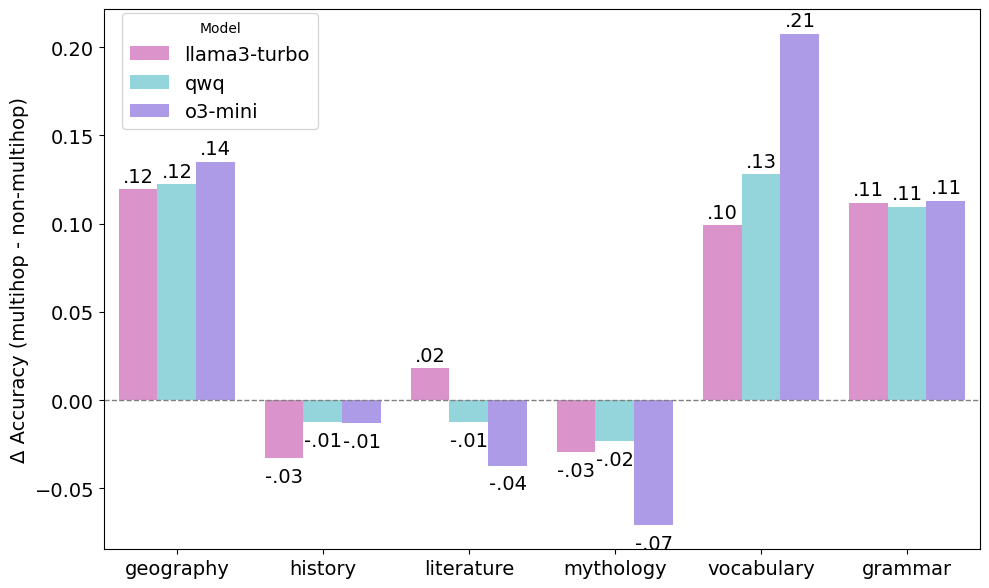

In [126]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=diff_df,
    x="question_content",
    y="diff",
    hue="model",
    palette=colors,  # same color dict you used before
    order=multihop_ordering,  # if you want consistent x-axis order
)

ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.set_ylabel("Δ Accuracy (multihop - non-multihop)", fontsize=14)
ax.set_xlabel("")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.isna(height):
            continue
        # position label above or below depending on sign
        y_offset = 0.002 if height >= 0 else -0.005
        txt = f"{height:.2f}"[1:] if height >= 0 else '-'+f"{height:.2f}"[2:]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + y_offset,
            txt,
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=14,
        )

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(0.01, 1.01), fontsize=14)
plt.tight_layout()
plt.show()